## Fashion-MNIST Binary Classification

### Importing main libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Configuring the default styling for all plots
(Specific styles can be applied to individual plots as needed.)

In [55]:
plt.rcParams['figure.figsize'] = [8, 6] # Width and height in inches
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['lines.linewidth'] = 1.3 # For plots with lines # Default
plt.rcParams['lines.markersize'] = 6 # For plots with markers (e.g. scatter plot)
plt.rcParams['axes.linewidth'] = 1 # Width of the border of the plot
plt.rcParams['axes.edgecolor'] = 'grey' # Colour of the border of the plot
plt.rcParams['axes.titlepad'] = 20 # Padding between title and plot
plt.rcParams['axes.labelpad'] = 10 # Padding between axis label and plot

# Colour cycle
color_list = ['darkblue', 'darkred', 'darkgreen', 'darkorange']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list) 

# Enable and style grid lines for better data visualisation
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.axisbelow'] = True # Ensure grid lines are behind plot elements

# Display plots inline directly below the relevant code cells so that plt.show() is not required
%matplotlib inline

### Loading the data

In [56]:
training_set = pd.read_csv('FMNIST_training_set.csv', header=None) # No header is present in the data files, so we need to specify that
training_labels = pd.read_csv('FMNIST_training_set_labels.csv', header=None)
test_set = pd.read_csv('FMNIST_test_set.csv', header=None)
test_labels = pd.read_csv('FMNIST_test_set_labels.csv', header=None)

### D1

#### 1. Processing the datasets

In [57]:
# Combine the datasets with their corresponding labels
training_combined = pd.concat([training_labels, training_set], axis=1) # axis=1 means concatenate along columns
test_combined = pd.concat([test_labels, test_set], axis=1)

# Filter for Sneakers (label 7) and Sandals (label 5)
training_filtered = training_combined[training_combined.iloc[:, 0].isin([5, 7])]
test_filtered = test_combined[test_combined.iloc[:, 0].isin([5, 7])]

# Map the labels of Sneaker and Sandal to 0 and 1 respectively
training_filtered.iloc[:, 0] = training_filtered.iloc[:, 0].map({7: 0, 5: 1})
test_filtered.iloc[:, 0] = test_filtered.iloc[:, 0].map({7: 0, 5: 1})

#### 2. Checking the filtered datasets

In [58]:
# Adjust display settings to show more columns
pd.set_option('display.max_columns', 50)

# Print the first 5 rows of each set
print("First 5 rows of the filtered training set:")
print(training_filtered.head())

print("\nFirst 5 rows of the filtered test set:")
print(test_filtered.head())

First 5 rows of the filtered training set:
    0    0    1    2    3    4    5    6    7    8    9    10   11   12   13   \
12    1    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
30    1    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
36    1    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
41    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0   
43    1    0    0    0    0    0    0    0    0    0    0    0    0    0    0   

    14   15   16   17   18   19   20   21   22   23   ...  759  760  761  762  \
12    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
30    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
36    0    0    0    0    0   53  102  144  169  149  ...    0    0    0   39   
41    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
43    0    0    0    0    0    0    0    0    0    0  ...    0   

The first five instances in the filtered training set match those illustrated on page 3 of the Assignment Document.

#### 3. Summarising the datasets

In [59]:
# Count the number of instances in each set and the total
num_training_instances = training_filtered.shape[0] # shape[0] gives the number of rows
num_test_instances = test_filtered.shape[0]
total_instances = num_training_instances + num_test_instances

print("Number of instances in the training set:", num_training_instances)
print("Number of instances in the test set:", num_test_instances)
print("Total number of instances:", total_instances)

Number of instances in the training set: 11988
Number of instances in the test set: 2000
Total number of instances: 13988


### D2

#### 1. Counting the instances in the training set

In [60]:
# Count the number of instances for each class label
label_counts = training_filtered.iloc[:, 0].value_counts().sort_index() # sort_index() sorts the counts by the index (class label)

# Print the counts
print(f"Number of Sneakers (0): {label_counts.loc[0]}")
print(f"Number of Sandals (1): {label_counts.loc[1]}")

Number of Sneakers (0): 5994
Number of Sandals (1): 5994


#### 2. Creating a bar plot for the training set

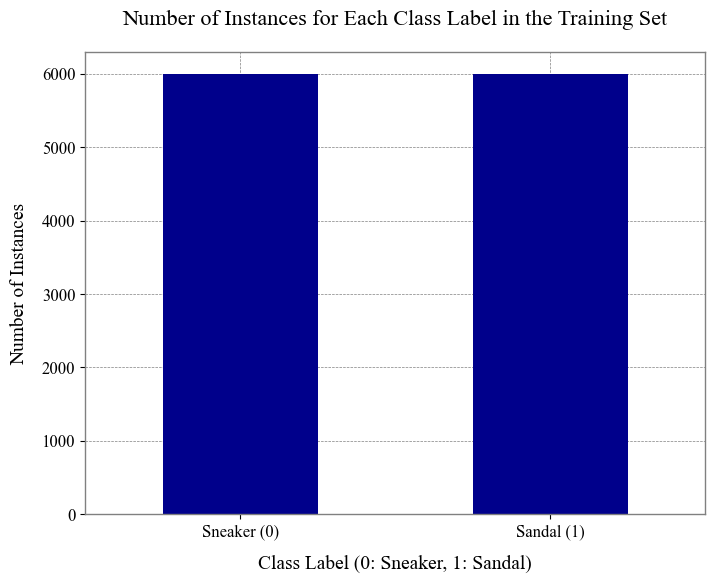

In [61]:
label_counts.plot(kind='bar')
plt.title('Number of Instances for Each Class Label in the Training Set')
plt.xlabel('Class Label (0: Sneaker, 1: Sandal)')
plt.ylabel('Number of Instances')
plt.xticks(ticks=[0, 1], labels=['Sneaker (0)', 'Sandal (1)'], rotation=0); # In response to the global application of "%matplotlib inline", add a semicolon at the end of the plotting command to suppress the display of unwanted text output (like object references) in the notebook.

### D3

#### Ploting the first six images from each class in the training set 

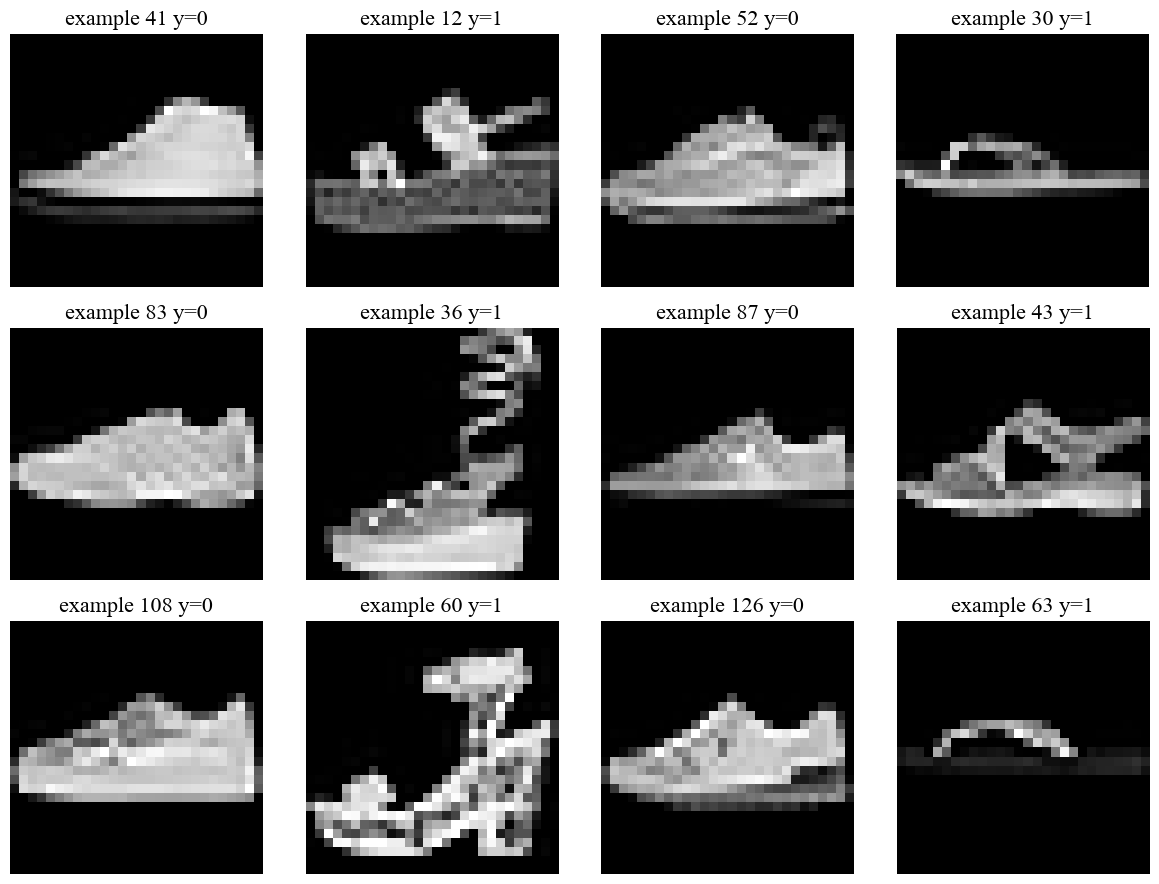

In [62]:
# Create a 3x4 grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# Filter examples for each class
sneakers = training_filtered[training_filtered.iloc[:, 0] == 0]
sandals = training_filtered[training_filtered.iloc[:, 0] == 1]

for i in range(6): # The first 6 images from each class
  # Calculate the row and column positions (indexes) for Sneakers
  # Alternate the placement of Sneaker and Sandal images across the 3x4 grid
  row = i // 2 # 0 for the first two images, 1 for the next two, and 2 for the last two
  col_sneakers = (i % 2) * 2 # 0 for the 1st, 3rd, and 5th images, 2 for the 2nd, 4th, and 6th images

  # Plot Sneakers at position [row, col_sneakers]
  ax = axes[row, col_sneakers]
  image_data = sneakers.iloc[i, 1:].values.reshape(28, 28)  # Exclude the label column and reshape the 784 values into a 28x28 image
  ax.imshow(image_data, cmap='gray')  # Display the image in grayscale by mapping the numerical pixel values (0 to 255) to shades of gray accordingly
  ax.set_title(f"example {sneakers.index[i]} y=0", pad=7) # Indexes in the original training set are preserved in the filtered sets (sneakers and sandals); pad=7 overrides the default setting for space between the title and the plot
  ax.axis('off')  # Hide the axis to match the target presentation style

  # Calculate the column position for sandals
  col_sandals = col_sneakers + 1

  # Plot sandals at position [row, col_sandals]
  ax = axes[row, col_sandals]
  image_data = sandals.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(image_data, cmap='gray') 
  ax.set_title(f"example {sandals.index[i]} y=1", pad=7)
  ax.axis('off')

plt.tight_layout(); # Adjust the subplots to fit into the figure area

### D4

#### LR1 - Customised Logistic Regression Classifier (without regularisation and with a fixed validation set)

#### 1. Randomly choosing a set of learning rates ([0.000001, 0.00001, 0.0001, 0.001]) for experiment:

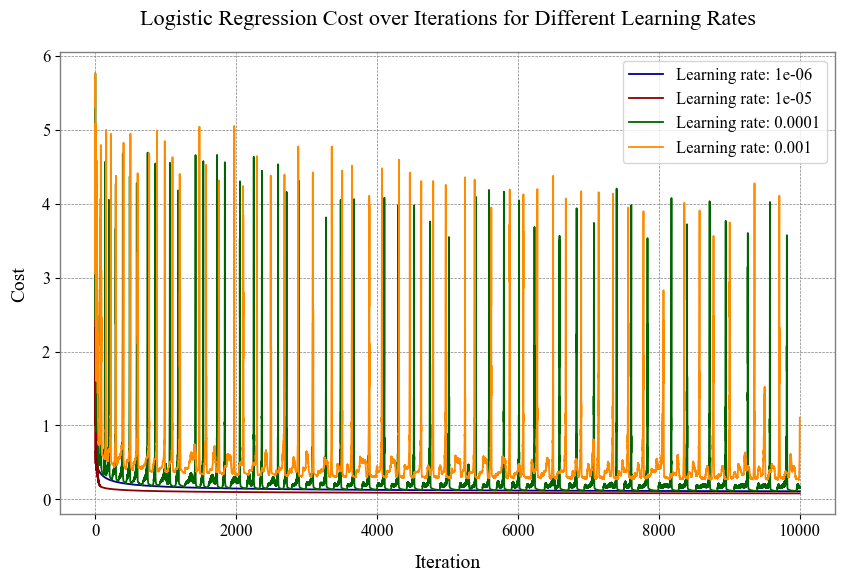

In [63]:
from sklearn.model_selection import train_test_split

# Set the random seed for reproducibility
np.random.seed(5508)

# X is the feature matrix (excluding the label column); y is the label vector (0 or 1)
X = training_filtered.iloc[:, 1:].values
y = training_filtered.iloc[:, 0].values.reshape(-1, 1) # Reshape it to a column vector

# Split the data into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=5508)

# Add intercept (bias) term of 1 to X_train and X_val
X_train = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1) # Add the bias to the first column
X_val = np.concatenate([np.ones((X_val.shape[0], 1)), X_val], axis=1)

# Sigmoid function to calculate probability
def sigmoid(z):
  z = np.clip(z, -250, 250) # Clip z to avoid numerical overflow
  return 1 / (1 + np.exp(-z))

# Logistic Regression cost function
def logistic_cost_function(X, y, theta):
  m = y.shape[0]
  h = sigmoid(X @ theta) # @ is the dot product operator in Python
  epsilon = 1e-5 # Add epsilon to prevent log(0), i.e. zero division error
  cost = -np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon)) / m
  return cost

# Learning rates to experiment with
learning_rates = [0.000001, 0.00001, 0.0001, 0.001] 

# Store the cost history for each learning rate
cost_history = {}

# Perform Batch Gradient Descent for each learning rate
for eta in learning_rates:
  theta = np.zeros((X_train.shape[1], 1)) # Reset the parameters for each learning rate
  cost_history[eta] = [] # Initialise the cost history for the current learning rate
  
  for iteration in range(10000):
    predictions = sigmoid(X_train @ theta)
    gradients = (X_train.T @ (predictions - y_train)) / y_train.size
    theta -= eta * gradients

    # Compute and store the cost every single iteration
    cost = logistic_cost_function(X_train, y_train, theta)
    cost_history[eta].append(cost)

# Plot the logistic regression cost over iterations for each learning rate
plt.figure(figsize=(10, 6))
for eta, costs in cost_history.items():
  plt.plot(costs, label=f'Learning rate: {eta}')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Logistic Regression Cost over Iterations for Different Learning Rates')
plt.legend();

#### 2. The plot above looks a bit messy and the lines are quite packed.  For better visualisation, 3 of the learning rates are selected for creating a plot separately:

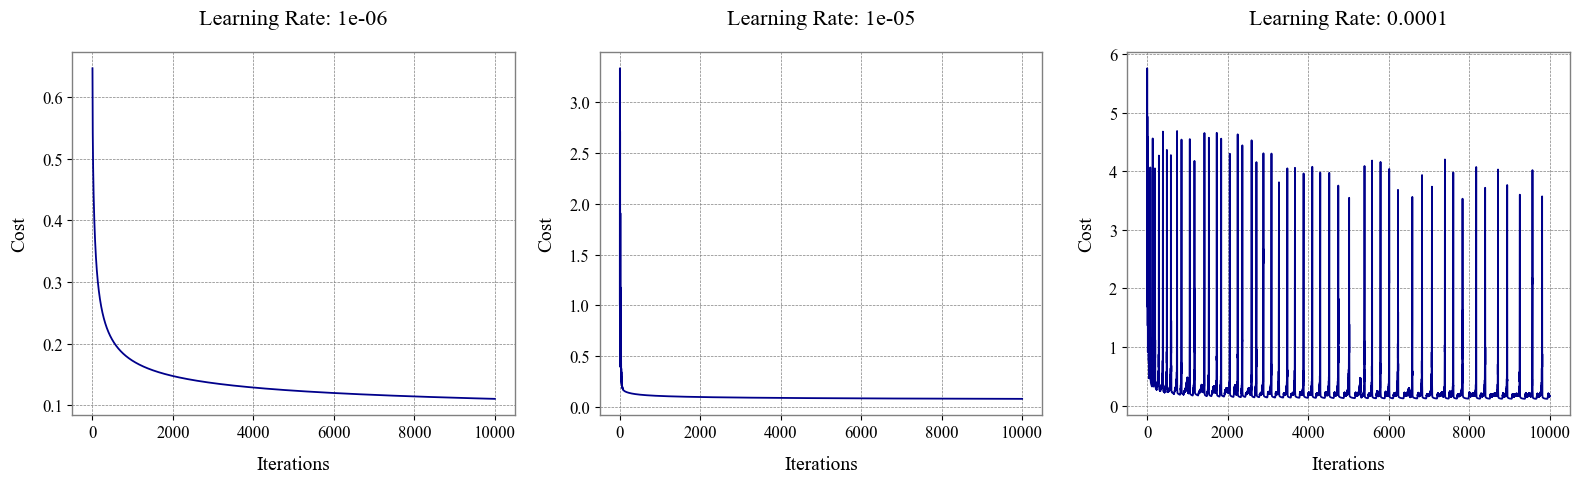

In [64]:
# Initialise figure for subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# Learning rates
learning_rates = [0.000001, 0.00001, 0.0001]

# Perform Batch Gradient Descent and plot for each learning rate
for i, eta in enumerate(learning_rates):
  # Initialise theta and cost history
  theta = np.zeros((X_train.shape[1], 1))
  cost_history = []
  
  # Perform gradient descent
  for iteration in range(10000):
    predictions = sigmoid(X_train @ theta)
    gradients = (X_train.T @ (predictions - y_train)) / y_train.size
    theta -= eta * gradients
    cost = logistic_cost_function(X_train, y_train, theta)
    cost_history.append(cost)
      
  # Plot cost history for the current learning rate
  ax = axes[i]
  ax.plot(range(10000), cost_history, label=f'LR: {eta}')
  ax.set_title(f'Learning Rate: {eta}')
  ax.set_xlabel('Iterations')
  ax.set_ylabel('Cost')

plt.tight_layout();

### D5 and D6

#### Two side-by-side plots for showing costs and misclassification fractions over each iteration:

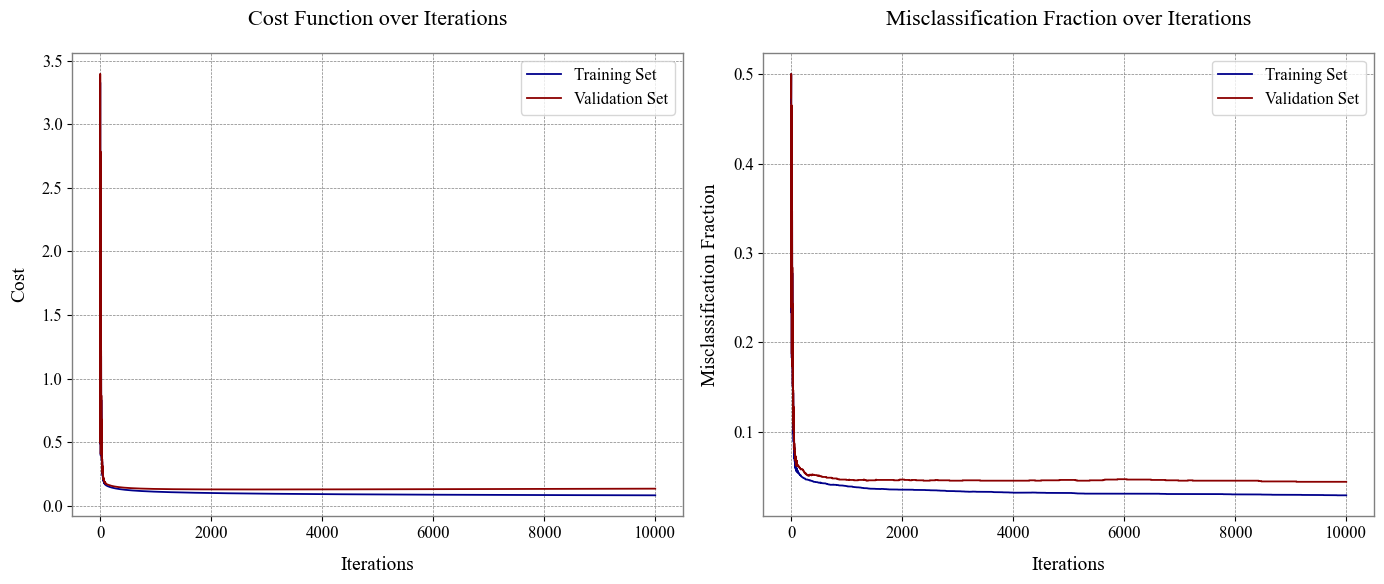

In [65]:
eta = 1e-5

# Initialise theta
theta = np.zeros((X_train.shape[1], 1))

# Function to compute the misclassification rate
def compute_misclassification(X, y, theta):
  # Apply logistic regression prediction rule: if the sigmoid function's output is >= 0.5 (threshold), classify as "1" (positive class), otherwise classify as "0" (negative class).
  predictions = sigmoid(X @ theta) >= 0.5
  
  # Misclassification rate = the fraction of predictions that do not match the labels = 1 - the proportion of correctly predicted labels
  misclassification = 1 - (predictions == y).mean()
  return misclassification

train_costs, val_costs = [], []
train_misclassifications, val_misclassifications = [], []

# Run the gradient descent for 10000 iterations to optimise parameters
for iteration in range(10000):
  # Calculate the predictions for training data
  train_predictions = sigmoid(X_train @ theta)
  
  # Calculate the gradient of the cost function with respect to parameters
  train_gradients = (X_train.T @ (train_predictions - y_train)) / y_train.size
  
  # Update the parameters by taking a step proportional to the gradient
  theta -= eta * train_gradients
  
  # Record the cost function value and misclassification rate for training data
  train_costs.append(logistic_cost_function(X_train, y_train, theta))
  train_misclassifications.append(compute_misclassification(X_train, y_train, theta))
  
  # Record the cost function value and misclassification rate for validation data
  val_costs.append(logistic_cost_function(X_val, y_val, theta))
  val_misclassifications.append(compute_misclassification(X_val, y_val, theta))

plt.figure(figsize=(14, 6))

# Left plot - Cost function values
plt.subplot(1, 2, 1)
plt.plot(range(10000), train_costs, label='Training Set')
plt.plot(range(10000), val_costs, label='Validation Set')
plt.title('Cost Function over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()

# Right plot - Misclassification fraction
plt.subplot(1, 2, 2)
plt.plot(range(10000), train_misclassifications, label='Training Set')
plt.plot(range(10000), val_misclassifications, label='Validation Set')
plt.title('Misclassification Fraction over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Misclassification Fraction')
plt.legend()

plt.tight_layout();

### D7

#### LR2 - Customised Logistic Regression Classifier (with regularisation and a fixed validation set)

##### Two side-by-side plots for showing costs and misclassification fractions over each C value:

The best C value is: 0.06210169418915629


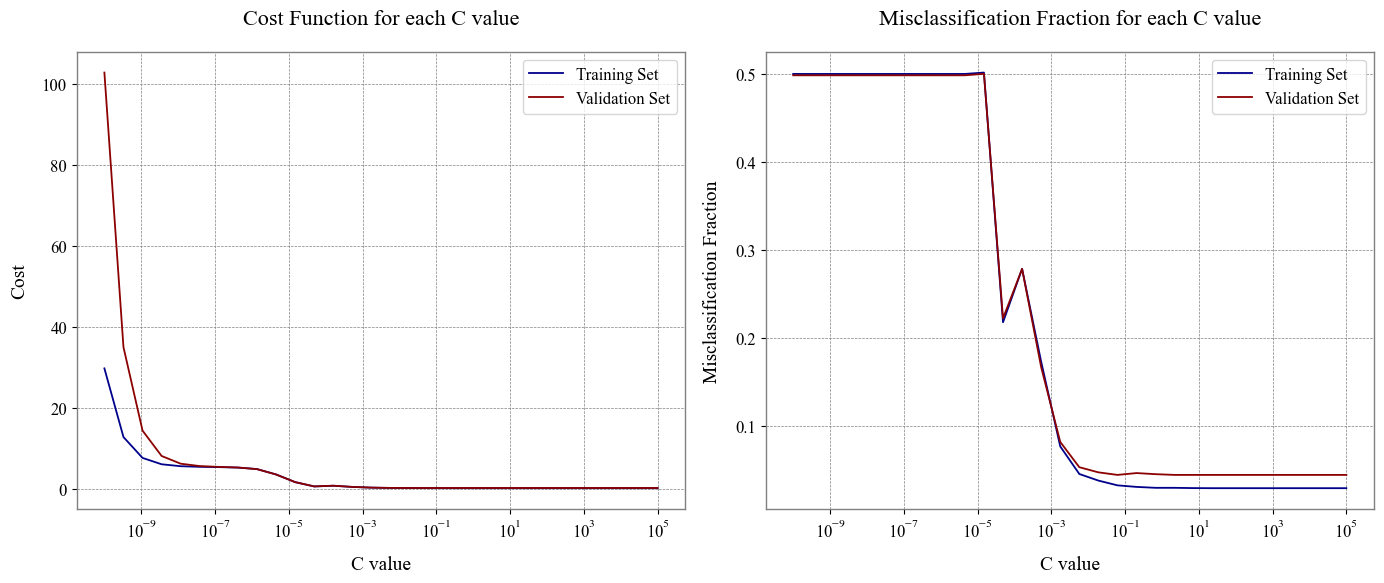

In [66]:
# Set a small value to prevent log(0) / division by zero issues in the computations below
epsilon = 1e-5

# Logistic Regression cost function with regularisation
def logistic_cost_function_reg(theta, X, y, C):
  m = len(y)
  theta = theta.reshape(-1, 1) # Ensure theta is a column vector
  h = sigmoid(X @ theta)
  h = np.clip(h, epsilon, 1 - epsilon)
  regularization = (1 / (2 * m)) * np.sum(theta[1:]**2) / C
  cost = -np.sum(y * np.log(h) + (1 - y) * np.log(1 - h)) / m + regularization
  return cost

# Gradient of the cost function with regularisation
def logistic_gradient_reg(theta, X, y, C):
  m = len(y)
  theta = theta.reshape(-1, 1)
  z = X @ theta
  z = np.clip(z, -500, 500) # Cap z to avoid overflow in sigmoid
  h = sigmoid(z)
  error = h - y
  regularization = np.vstack([0, theta[1:] / (C + epsilon)])
  gradient = X.T @ error / m + regularization
  return gradient.flatten()

# Train logistic regression model using manual gradient descent
def train_logistic_regression_gd(X, y, C, max_iter, learning_rate):
  theta = np.zeros((X.shape[1], 1)) # Initialise theta
  for _ in range(max_iter):
    gradient = logistic_gradient_reg(theta, X, y, C).reshape(-1, 1) # Reshape gradient to column vector
    theta -= learning_rate * gradient # Perform the gradient update
  return theta

# Calculate misclassification fraction
def calculate_misclassification_fraction(predictions, y):
  predicted_labels = predictions >= 0.5
  misclassification_fraction = np.mean(predicted_labels != y)
  return misclassification_fraction

# Evaluate the model with different C values using fixed validation set
def validate_logistic_regression(X_train, y_train, X_val, y_val, C_values, max_iter, learning_rate):
  best_C = None
  lowest_val_loss = np.inf
  train_costs, val_costs, train_misclassifications, val_misclassifications = [], [], [], []

  for C in C_values:
    theta = train_logistic_regression_gd(X_train, y_train, C, max_iter, learning_rate)
    train_preds = sigmoid(X_train @ theta)
    val_preds = sigmoid(X_val @ theta)

    train_cost = logistic_cost_function_reg(theta, X_train, y_train, C)
    val_cost = logistic_cost_function_reg(theta, X_val, y_val, C)
    train_costs.append(train_cost)
    val_costs.append(val_cost)

    train_misclass = calculate_misclassification_fraction(train_preds, y_train)
    val_misclass = calculate_misclassification_fraction(val_preds, y_val)
    train_misclassifications.append(train_misclass)
    val_misclassifications.append(val_misclass)

    if val_cost < lowest_val_loss:
      lowest_val_loss = val_cost
      best_C = C

  return best_C, train_costs, val_costs, train_misclassifications, val_misclassifications

# Define the range of C values to explore (as specified in the instruction)
C_range = np.logspace(-10, 5, 30)

# Apply the best learning rate from D4
learning_rate = 0.00001

# Find the best C value and associated costs and misclassifications
best_C, train_costs, val_costs, train_misclassifications, val_misclassifications = validate_logistic_regression(
  X_train, y_train, X_val, y_val, C_range, 10000, learning_rate
)

print(f"The best C value is: {best_C}")

# Plot the results
plt.figure(figsize=(14, 6))

# Left Plot - Cost Function for each C value
plt.subplot(1, 2, 1)
plt.semilogx(C_range, train_costs, label='Training Set')
plt.semilogx(C_range, val_costs, label='Validation Set')
plt.title('Cost Function for each C value')
plt.xlabel('C value')
plt.ylabel('Cost')
plt.legend()

# Right Plot - Misclassification Fraction for each C value
plt.subplot(1, 2, 2)
plt.semilogx(C_range, train_misclassifications, label='Training Set')
plt.semilogx(C_range, val_misclassifications, label='Validation Set')
plt.title('Misclassification Fraction for each C value')
plt.xlabel('C value')
plt.ylabel('Misclassification Fraction')
plt.legend()

plt.tight_layout();

### D8 and D9

#### LR3 - Scikit-Learn Logistic Regression Classifier (using 10-fold cross-validation)

#### Two side-by-side plots for showing costs and misclassification fractions over each C value:

The best C value based on log loss is: 0.018873918221350997
The corresponding lowest mean log loss is: 0.11364926294234881
The best C value based on accuracy is: 0.018873918221350997
The corresponding lowest mean misclassification fraction is: 0.03972888425443166


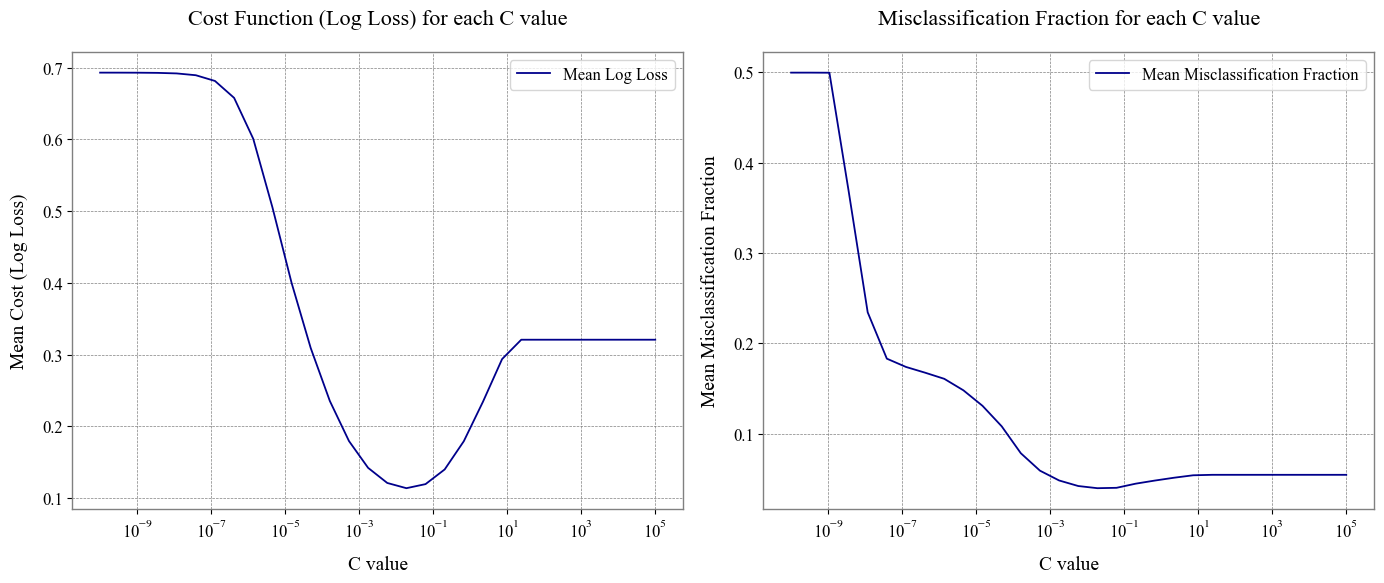

In [85]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

# Scale the features to have a mean of 0 and a variance of 1
# This step is necessary to prevent the logistic regression algorithm from failing to converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) # For D10

# Ensure that y_train is a 1D array (required for LogisticRegressionCV)
y_train = y_train.ravel()

# Initialise LogisticRegressionCV for log loss
log_reg_cv_log_loss = LogisticRegressionCV(Cs=C_range, cv=10, max_iter=10000, scoring='neg_log_loss') # C_range is previously defined in D7 as np.logspace(-10, 5, 30)
log_reg_cv_log_loss.fit(X_train_scaled, y_train)

# Initialise LogisticRegressionCV for accuracy
log_reg_cv_accuracy = LogisticRegressionCV(Cs=C_range, cv=10, max_iter=10000, scoring='accuracy')
log_reg_cv_accuracy.fit(X_train_scaled, y_train)

# Extract the mean test scores (negative log loss) across all 10 folds for each C value
mean_scores_log_loss = -log_reg_cv_log_loss.scores_[1].mean(axis=0) # Negate to interpret as cost

# Extract the mean test scores (accuracy) and compute misclassification rate
mean_scores_accuracy = log_reg_cv_accuracy.scores_[1].mean(axis=0)
misclassification_rate = 1 - mean_scores_accuracy

# Note: LogisticRegressionCV in Scikit-Learn defaults to a 0.5 threshold for binary classification. Accuracy and misclassification (1 - accuracy) metrics implicitly use this threshold.

# Plot the cross-validation results
plt.figure(figsize=(14, 6))

# Left Plot - Cost Function (Log Loss) for each C value
plt.subplot(1, 2, 1)
plt.semilogx(C_range, mean_scores_log_loss, label='Mean Log Loss')
plt.title('Cost Function (Log Loss) for each C value')
plt.xlabel('C value')
plt.ylabel('Mean Cost (Log Loss)')
plt.legend()

# Right Plot - Misclassification Rate for each C value
plt.subplot(1, 2, 2)
plt.semilogx(C_range, misclassification_rate, label='Mean Misclassification Fraction')
plt.title('Misclassification Fraction for each C value')
plt.xlabel('C value')
plt.ylabel('Mean Misclassification Fraction')
plt.legend()

plt.tight_layout()

# Display the best C value based on log loss and its corresponding score
best_C_log_loss = log_reg_cv_log_loss.C_[0]
mean_scores_log_loss = -log_reg_cv_log_loss.scores_[1].mean(axis=0)
best_index_log_loss = np.where(log_reg_cv_log_loss.Cs_ == best_C_log_loss)[0][0]
best_score_log_loss = mean_scores_log_loss[best_index_log_loss]
print(f"The best C value based on log loss is: {best_C_log_loss}")
print(f"The corresponding lowest mean log loss is: {best_score_log_loss}")

# Display the best C value based on accuracy and its corresponding score
best_C_accuracy = log_reg_cv_accuracy.C_[0]
mean_scores_accuracy = log_reg_cv_accuracy.scores_[1].mean(axis=0)
best_index_accuracy = np.where(log_reg_cv_accuracy.Cs_ == best_C_accuracy)[0][0]
best_score_accuracy = mean_scores_accuracy[best_index_accuracy]
misclassification_fraction_accuracy = 1 - best_score_accuracy
print(f"The best C value based on accuracy is: {best_C_accuracy}")
print(f"The corresponding lowest mean misclassification fraction is: {misclassification_fraction_accuracy}")

### D10 and D11

#### LR4 - Scikit-Learn Stochastic Gradient Descent (SGD) Classifier (using 10-fold cross-validation)

In [81]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Scaling on X_train and X_val performed in D8

# Transformation of y_train into a 1D array performed in D8 (required for SGDClassifier)

# Initialise SGDClassifier for logistic regression with log loss
sgd_classifier = SGDClassifier(loss='log_loss', max_iter=10000, random_state=5508)

# Define the range of alpha values to explore (alpha is the inverse of regularisation strength C), as SGDClassifier uses alpha instead of C for regularisation
alpha_range = 1 / C_range

# Define parameter grid for GridSearchCV
param_grid = {'alpha': alpha_range}

# # Set up the Grid Search with cross-validation for SGDClassifier to optimise the cost function
grid_search_sgd_log_loss = GridSearchCV(estimator=sgd_classifier, param_grid=param_grid, cv=10, scoring='neg_log_loss', return_train_score=True)

# Set up the Grid Search with cross-validation for SGDClassifier to optimise accuracy
grid_search_sgd_accuracy = GridSearchCV(estimator=sgd_classifier, param_grid=param_grid, cv=10, scoring='accuracy', return_train_score=True)

# Perform grid searches for negative log loss and accuracy
grid_search_sgd_log_loss.fit(X_train_scaled, y_train)
grid_search_sgd_accuracy.fit(X_train_scaled, y_train)

# Identify best alpha index and value for log loss
best_alpha_index_log_loss = grid_search_sgd_log_loss.best_index_
best_alpha_log_loss = grid_search_sgd_log_loss.best_params_['alpha']

# Identify best alpha index and value for accuracy
best_alpha_index_accuracy = grid_search_sgd_accuracy.best_index_
best_alpha_accuracy = grid_search_sgd_accuracy.best_params_['alpha']

# Convert alpha back to C for reporting purpose
optimal_C_value_log_loss = 1 / best_alpha_log_loss
optimal_C_value_accuracy = 1 / best_alpha_accuracy

# Retrieve the cost function values for training and validation sets
cost_function_training = -grid_search_sgd_log_loss.cv_results_['mean_train_score'][best_alpha_index_log_loss] # Negate to interpret as cost
cost_function_validation = -grid_search_sgd_log_loss.cv_results_['mean_test_score'][best_alpha_index_log_loss]

# Retrieve the accuracy for training and validation sets
# Misclassification fraction = 1 - accuracy
misclassification_fraction_training = 1 - grid_search_sgd_accuracy.cv_results_['mean_train_score'][best_alpha_index_accuracy]
misclassification_fraction_validation = 1 - grid_search_sgd_accuracy.cv_results_['mean_test_score'][best_alpha_index_accuracy]

# Create a dictionary with the results
results = {
  'Metric': ['Optimal C (Log Loss)', 'Optimal C (Accuracy)', 'Training Set - Cost Function', 'Validation Set - Cost Function', 'Training Set - Misclassification', 'Validation Set - Misclassification'],
  'Value': [
    optimal_C_value_log_loss,
    optimal_C_value_accuracy, 
    cost_function_training, 
    cost_function_validation, 
    misclassification_fraction_training, 
    misclassification_fraction_validation
  ]
}

# Display a DataFrame for the results dictionary
df_results = pd.DataFrame(results)
print(df_results)

                               Metric      Value
0                Optimal C (Log Loss)  78.804628
1                Optimal C (Accuracy)  78.804628
2        Training Set - Cost Function   0.100948
3      Validation Set - Cost Function   0.136124
4    Training Set - Misclassification   0.032534
5  Validation Set - Misclassification   0.041084


### D12

#### Precision versus Recall:

Optimal threshold based on balance between precision and recall: 0.6386405683761379


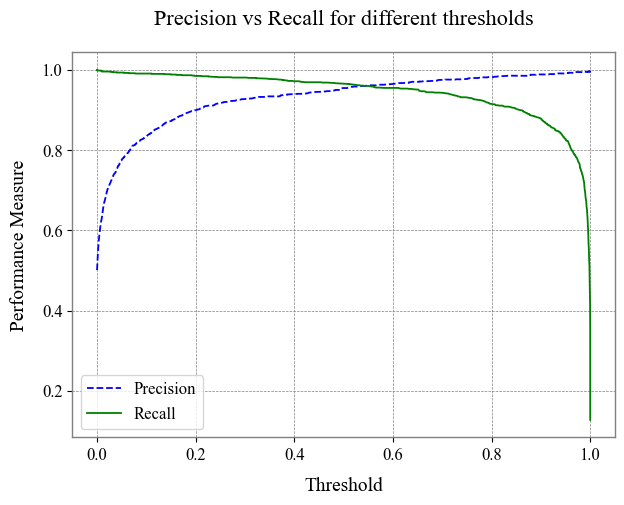

In [92]:
from sklearn.metrics import precision_recall_curve

alpha = 1 / optimal_C_value_log_loss

# Retrain SGDClassifier with the optimal C value from the Grid Search in D10
sgd_clf = SGDClassifier(loss='log_loss', alpha=alpha, max_iter=10000, random_state=5508)
sgd_clf.fit(X_train_scaled, y_train)

# Predict probabilities on the validation set
y_scores = sgd_clf.predict_proba(X_val_scaled)[:, 1] # Get the scores for the positive class

# Compute precision and recall for various thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)

# Plot precision vs recall for different threshold values
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel('Threshold')
plt.ylabel('Performance Measure')
plt.title('Precision vs Recall for different thresholds')
plt.legend(loc="best") # Automatically place the legend in the best position

# Find the optimal threshold based on the balance between precision and recall
optimal_threshold_index = np.argmax(precisions + recalls) # Find the index where the sum of precision and recall is maximised
optimal_threshold = thresholds[optimal_threshold_index]
print(f"Optimal threshold based on balance between precision and recall: {optimal_threshold}");

### D13

#### Fine-tuning the optimal threshold value using the validation set:

In [94]:
from sklearn.metrics import f1_score

# Predicted probabilities on the validation set
y_scores = sgd_clf.predict_proba(X_val_scaled)[:, 1]

# Define a range of potential thresholds
thresholds = np.linspace(0.1, 0.9, 50)

# Find the threshold that maximises the F1 score
best_threshold = 0
best_f1 = 0

for threshold in thresholds:
  # Apply threshold to positive class probabilities to create predictions
  y_pred = (y_scores > threshold).astype(int) # Convert boolean to integer (False to 0, True to 1)
  
  # Calculate F1 score (harmonic mean of precision and recall)
  f1 = f1_score(y_val, y_pred)
  
  # Update best threshold if this threshold has a better F1 score
  if f1 > best_f1:
    best_f1 = f1
    best_threshold = threshold

# Print the optimal threshold
print(f"Optimal threshold based on F1 score: {best_threshold}")

Optimal threshold based on F1 score: 0.6387755102040816


Note: By manually searching for the threshold that maximises the F1 score while fixing the optimal regularisation parameter C, it is effectively conducting a grid search over the threshold values by focusing on fine-tuning the decision threshold based on model performance on the validation set.

### D14 and D15

#### LR1 to LR4 - Performance Evaluation

##### 1. Data processing for the test set

In [121]:
# Prepare the feature set for the test data excluding the bias term
X_test = test_filtered.iloc[:, 1:].values  # Excludes the label column
y_test = test_filtered.iloc[:, 0].values

# Initialise the scaler using X_train without the bias term
scaler = StandardScaler()
X_train_features = X_train[:, 1:] # Excluding the first column of X_train which is the bias term
scaler.fit(X_train_features)

# Scale X_test features without bias
X_test_scaled_features = scaler.transform(X_test)

# Set up scaled X_test with unscaled bias
bias_term = np.ones((X_test_scaled_features.shape[0], 1)) # Create a column of ones (bias)
X_test_scaled = np.concatenate([bias_term, X_test_scaled_features], axis=1) # Add the bias to the first column of X_test_scaled_features

##### 2. LR1's performance on the test set:

In [129]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Compute the optimal theta based on LR1
best_learning_rate = 0.00001 # From D4

# Re-initialise theta for the best learning rate
theta = np.zeros((X_train.shape[1], 1))

# Ensure y_train is a column vector
y_train = y_train.reshape(-1, 1)

# Rerun gradient descent with the best learning rate
cost_history_best_lr = []
for iteration in range(10000):
  predictions = sigmoid(X_train @ theta)
  gradients = (X_train.T @ (predictions - y_train)) / y_train.size
  theta -= best_learning_rate * gradients
  cost = logistic_cost_function(X_train, y_train, theta)
  cost_history_best_lr.append(cost)

# Trained theta based on the best learning rate
optimal_theta = theta

# Make predictions on the test set
y_pred_proba = sigmoid(X_test_scaled @ optimal_theta)
y_pred_test = (y_pred_proba >= 0.5).astype(int)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
FP = conf_matrix[0][1]
TN = conf_matrix[0][0]
FPR = FP / (FP + TN)

# Display the metrics
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("False Positive Rate:", FPR)

Confusion Matrix:
 [[987  13]
 [152 848]]
Precision: 0.9849012775842044
Recall: 0.848
False Positive Rate: 0.013


##### 3. LR2's performance on the test set:

In [130]:
# Retrain the model on the entire training set with the best C from D7 and the best learning rate from D4
optimal_theta = train_logistic_regression_gd(X_train, y_train, best_C, 10000, 0.00001)

# Predict probabilities on the test set
y_pred_proba_test = sigmoid(X_test_scaled @ optimal_theta)
y_pred_test = (y_pred_proba_test >= 0.5).astype(int)  # Apply threshold

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
FP = conf_matrix[0][1]
TN = conf_matrix[0][0]
FPR = FP / (FP + TN)

# Display the metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"False Positive Rate: {FPR}")

Confusion Matrix:
 [[986  14]
 [131 869]]
Precision: 0.984144960362401
Recall: 0.869
False Positive Rate: 0.014


##### 4. LR3's performance on the test set:

In [132]:
# Predict class labels for the test set
y_pred_test = log_reg_cv_log_loss.predict(X_test_scaled) # or log_reg_cv_accuracy.predict(X_test_scaled)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
FP = conf_matrix[0][1]
TN = conf_matrix[0][0]
FPR = FP / (FP + TN)

# Display the metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"False Positive Rate: {FPR:.4f}")

Confusion Matrix:
 [[968  32]
 [ 44 956]]
Precision: 0.9676
Recall: 0.9560
False Positive Rate: 0.0320


##### 5. LR4's performance on the test set:

In [122]:
# Initialise and train the model with the specified alpha (inverse of C)
alpha = 1 / 78.805 # Optimal C from D10 = 78.805

sgd_clf = SGDClassifier(loss='log_loss', alpha=alpha, max_iter=10000, random_state=5508)
sgd_clf.fit(X_train_scaled, y_train)

# Predict probabilities on the test set using X_test_scaled_no_bias
y_scores_test = sgd_clf.predict_proba(X_test_scaled)[:, 1] # Get the scores for the positive class

# Apply the optimal threshold from D13 to make final predictions
y_pred_test = (y_scores_test >= 0.639).astype(int)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
FP = conf_matrix[0][1]
TN = conf_matrix[0][0]
FPR = FP / (FP + TN)

# Display the metrics
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("False Positive Rate:", FPR)

Confusion Matrix:
 [[969  31]
 [ 52 948]]
Precision: 0.9683350357507661
Recall: 0.948
False Positive Rate: 0.031


### D16 and D17

#### LR4 - False Positives and Negatives Analysis

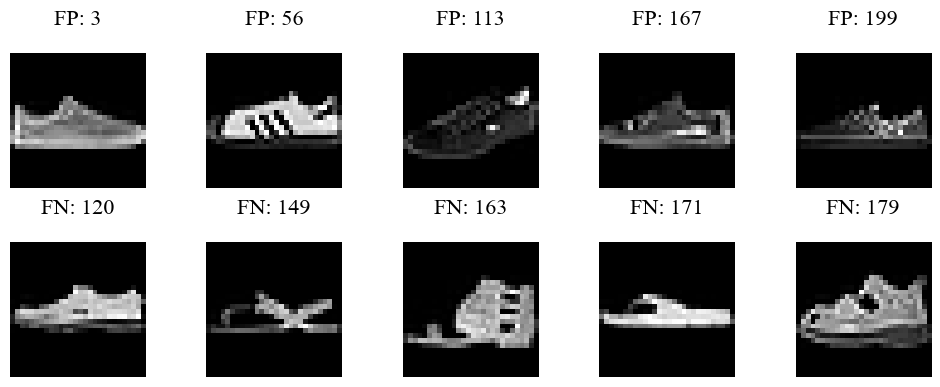

In [133]:
# Identify false positives and negatives based on y_test (true labels) and y_pred_test (predicted labels) from LR4
false_positives = (y_test == 0) & (y_pred_test == 1)
false_negatives = (y_test == 1) & (y_pred_test == 0)

# Extract indexes of the false positives and negatives
fp_indexes = np.where(false_positives)[0]
fn_indexes = np.where(false_negatives)[0]

# Plot the images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes[0, :]):
  # Show false positive images
  ax.imshow(X_test[fp_indexes[i]].reshape(28, 28), cmap='gray')
  ax.axis('off')
  ax.set_title(f'FP: {fp_indexes[i]}')

for i, ax in enumerate(axes[1, :]):
  # Show false negative images
  ax.imshow(X_test[fn_indexes[i]].reshape(28, 28), cmap='gray')
  ax.axis('off')
  ax.set_title(f'FN: {fn_indexes[i]}')

plt.tight_layout();

### D18 and D19

#### LR4 - Weights Matrix / Visualisation

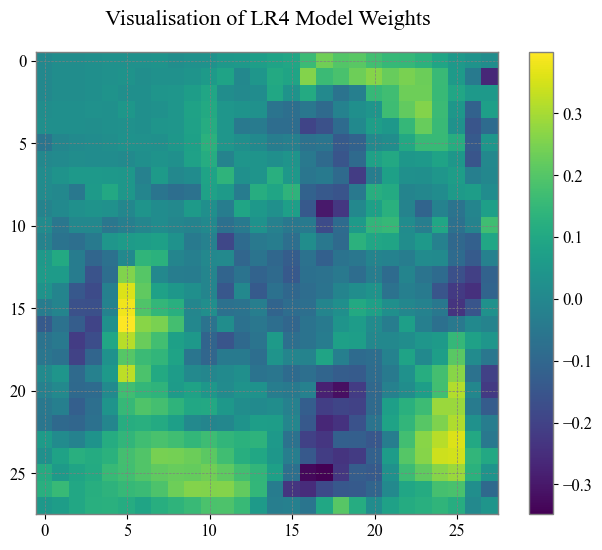

In [135]:
# Extract the weights (excluding the bias term, if present)
weights = sgd_clf.coef_.flatten()[1:] # Exclude the first element (bias)

# Reshape the weights into a 28x28 matrix
weights_matrix = weights.reshape(28, 28)

# Visualise the weights matrix using imshow() function
plt.imshow(weights_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Visualisation of LR4 Model Weights');

### D20 and D21

#### k-Nearest Neighbours (k-NN) algorithm (with Euclidean distance) for binary classification

The best k value within an acceptable gap of 0.01 is 7,
with a validation misclassification fraction of 0.06,
and a training-validation gap of 0.01


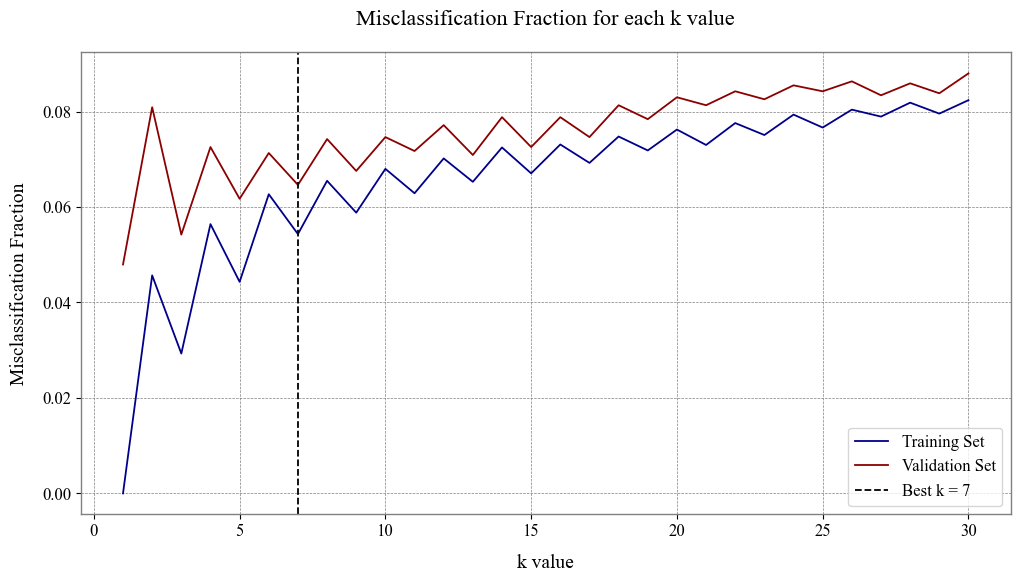

In [151]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the range of k values to try
k_values = range(1, 31)

# Flatten y_train and y_val to be one-dimensional arrays for compatibility with Scikit-Learn
y_train = y_train.ravel()
y_val = y_val.ravel()

# Initialise lists to store misclassification fractions and their differences
training_errors, validation_errors, gap_differences = [], [], []

# Loop over values of k to find the best k
for k in k_values:
  # Initialise k-NN classifier with the current k
  knn = KNeighborsClassifier(n_neighbors=k) # By default, the k-NN classifier in Scikit-Learn applies the Euclidean distance (i.e. p=2 and metric='minkowski', which is equivalent to the Euclidean distance metric)
  
  # Train the classifier
  knn.fit(X_train, y_train)
  
  # Make predictions on the training and validation sets
  y_train_pred = knn.predict(X_train)
  y_val_pred = knn.predict(X_val)
  
  # Calculate misclassification fraction (1 - accuracy)
  training_error = 1 - accuracy_score(y_train, y_train_pred)
  validation_error = 1 - accuracy_score(y_val, y_val_pred)
  
  # Store the results
  training_errors.append(training_error)
  validation_errors.append(validation_error)
  gap_differences.append(abs(validation_error - training_error))

# Set a maximum acceptable gap between training and validation errors
max_acceptable_gap = 0.0104 # Initially set to 0.01 but later found a marginal gap of 0.0103 at k=7 which is acceptable

# Find the k within the acceptable gap with the smallest validation error (misclassification fraction)
best_k_within_gap = min(
  ((k, validation_errors[i], gap_differences[i]) for i, k in enumerate(k_values) if gap_differences[i] <= max_acceptable_gap),
  key=lambda x: x[1]
)

best_k = best_k_within_gap[0]
best_validation_error = best_k_within_gap[1]
best_gap_difference = best_k_within_gap[2]

# Display the best k value
print(f"The best k value within an acceptable gap of {max_acceptable_gap:.2f} is {best_k},\nwith a validation misclassification fraction of {best_validation_error:.2f},\nand a training-validation gap of {best_gap_difference:.2f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(k_values, training_errors, label='Training Set')
plt.plot(k_values, validation_errors, label='Validation Set')
plt.axvline(x=best_k, color='k', linestyle='--', label=f'Best k = {best_k}')
plt.title('Misclassification Fraction for each k value')
plt.xlabel('k value')
plt.ylabel('Misclassification Fraction')
plt.legend();

### D22 and D23

#### k-NN algorithm - Performance Evaluation

In [158]:
# Best k value determined from D21
best_k = 7

# Initialise the k-NN classifier with the best k value
knn = KNeighborsClassifier(n_neighbors=best_k)

# Train the classifier using the training data
knn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_test = knn.predict(X_test_scaled)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
FP = conf_matrix[0][1]
TN = conf_matrix[0][0]
FPR = FP / (FP + TN)

# Display the metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"False Positive Rate: {FPR:.2f}")

Confusion Matrix:
 [[995   5]
 [131 869]]
Precision: 0.99
Recall: 0.87
False Positive Rate: 0.01
